## Bike Availability Forecasting using Time Series Analysis

To predict bike availability at stations using historical data and weather features

In [ ]:
# imports
import json
import pickle

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, mean_absolute_error, precision_score, recall_score, r2_score
from sklearn.model_selection import train_test_split

In [3]:
# Data Loading And Exploration

df_raw = pd.read_csv('final_merged_data.csv', low_memory=False)

print(f'Shape: {df_raw.shape}')
print(f'Rows: {len(df_raw):,}')
print(f'Stations: {df_raw["station_id"].nunique()}')
print(f'Data range: {df_raw["last_reported"].min()} -> {df_raw["last_reported"].max()}')
df_raw.head(3)


Shape: (298946, 78)
Rows: 298,946
Stations: 115
Data range: 2024-12-01 00:10:00 -> 2024-12-31 23:50:00


,last_reported,station_id,num_bikes_available,num_docks_available,is_installed,is_renting,is_returning,name,address,lat,...,min_humidity_quality_indicator,min_relative_humidity_percent,humidity_std_quality_indicator,relative_humidity_std_deviation,max_pressure_quality_indicator,max_barometric_pressure_hpa,min_pressure_quality_indicator,min_barometric_pressure_hpa,pressure_std_quality_indicator,barometric_pressure_std_deviation
0,2024-12-01 00:10:00,10,15,1,True,True,True,DAME STREET,Dame Street,53.344006,...,0,83.2,0,0.284,0,1002.56,0,1002.26,0,0.083
1,2024-12-01 00:10:00,100,17,8,True,True,True,HEUSTON BRIDGE (SOUTH),Heuston Bridge (South),53.347107,...,0,83.2,0,0.284,0,1002.56,0,1002.26,0,0.083
2,2024-12-01 00:10:00,109,20,9,True,True,True,BUCKINGHAM STREET LOWER,Buckingham Street Lower,53.353333,...,0,83.2,0,0.284,0,1002.56,0,1002.26,0,0.083


In [4]:
# Target variable description
# the model will predict num_bikes_available. Nedd to know its range.
# whether it is heavily skewed, whether extreme outliers could distort MAE, R**2
print('num_bikes_available:')
print(df_raw['num_bikes_available'].describe().round(2))

num_bikes_available:
count    298946.00
mean         12.20
std           9.76
min           0.00
25%           4.00
50%          11.00
75%          19.00
max          40.00
Name: num_bikes_available, dtype: float64


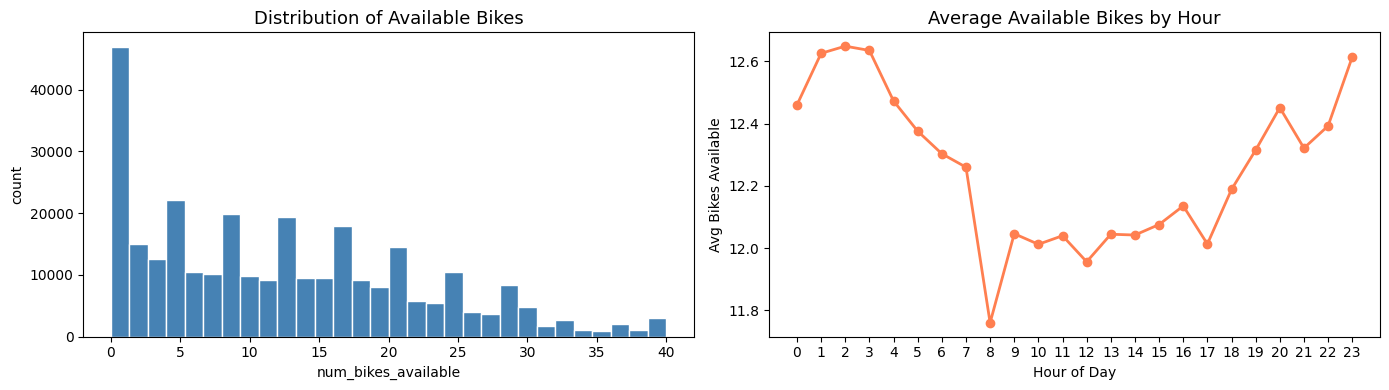

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df_raw['num_bikes_available'], bins=30, color='steelblue', edgecolor='white')

axes[0].set_title('Distribution of Available Bikes', fontsize=13)
axes[0].set_xlabel('num_bikes_available')
axes[0].set_ylabel('count')

hourly = df_raw.groupby('hour')['num_bikes_available'].mean()

axes[1].plot(hourly.index, hourly.values, marker='o', color='coral', linewidth=2)
axes[1].set_title('Average Available Bikes by Hour', fontsize=13)
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Avg Bikes Available')
axes[1].set_xticks(range(0, 24))

plt.tight_layout()
plt.show()

In [6]:
#Histogram on the left (bike counts): reveals the distribution shape (bell-curved, bimodal, mostly zeros, etc.)
#                                     A right heavy tail hints that capacity outliers exist 
#Subplot on the right (Average bikes by hour): a clear pattern confirms that 'hour' should be a useful predictor.


## Feature Engineering

**engineer averaged weather features:**  
The raw weather data contains separate max/min columns for temperature, humidity, and barometric pressure. Averaging max and min gives a simple, interpretable mid-day estimate and avoids multicollinearity between two highly correlated columns.

**add a binary target:**  
A binary question — "will there be at least 3 bikes available?" — maps directly to a user-facing map feature: a green/red station indicator. The threshold of 3 provides a safety margin for a planned journey.

**the candidate feature set was chosen:**  
We include temporal features (`hour`, `month`), `station_id` for per-station usage differences, `capacity` because larger stations hold more bikes, and the three averaged weather features. All other raw columns are dropped to reduce noise and keep the model lightweight for real-time EC2 inference.

In [7]:
df = df_raw.copy()

#(max+min)/2: Met Éireann provides daily extremes; their average approximates
# the daily mean and avoids multicollinearity between two correlated columns.

df['avg_temp'] = (df['max_air_temperature_celsius']   + df['min_air_temperature_celsius'])   / 2
df['avg_humidity'] = (df['max_relative_humidity_percent'] + df['min_relative_humidity_percent']) / 2
df['avg_pressure'] = (df['max_barometric_pressure_hpa']   + df['min_barometric_pressure_hpa'])   / 2

# threshold=3: gives the front-end a reliable 'station usable' flag.
df['bikes_available'] = (df['num_bikes_available'] >= 3).astype(int)

CANDIDATE_FEATURES = ['station_id', 'hour', 'month', 'capacity',
                          'avg_temp', 'avg_humidity', 'avg_pressure']
REGRESSION_TARGET = 'num_bikes_available'
CLASSIFICATION_TARGET = 'bikes_available'

df = df[CANDIDATE_FEATURES + [REGRESSION_TARGET, CLASSIFICATION_TARGET]].dropna()

print(f'Rows after dropna : {len(df):,}')
print(f'Class balance : bike available (1) = {df["bikes_available"].mean()*100:.1f}%')
df[CANDIDATE_FEATURES].describe().round(2)


Rows after dropna : 298,946
Class balance : bike available (1) = 79.3%


,station_id,hour,month,capacity,avg_temp,avg_humidity,avg_pressure
count,298946.00,298946.00,298946.0,298946.00,298946.00,298946.00,298946.00
mean,57.97,11.52,12.0,31.98,7.79,84.28,1014.77
std,33.96,6.28,0.0,7.46,3.13,8.00,11.86
min,1.00,0.00,12.0,16.00,-3.48,55.07,975.04
25%,28.00,7.00,12.0,29.00,5.68,79.77,1005.92
50%,57.00,12.00,12.0,30.00,7.87,85.35,1017.12
75%,88.00,16.00,12.0,40.00,10.12,89.60,1022.62
max,117.00,23.00,12.0,40.00,14.63,98.85,1035.78


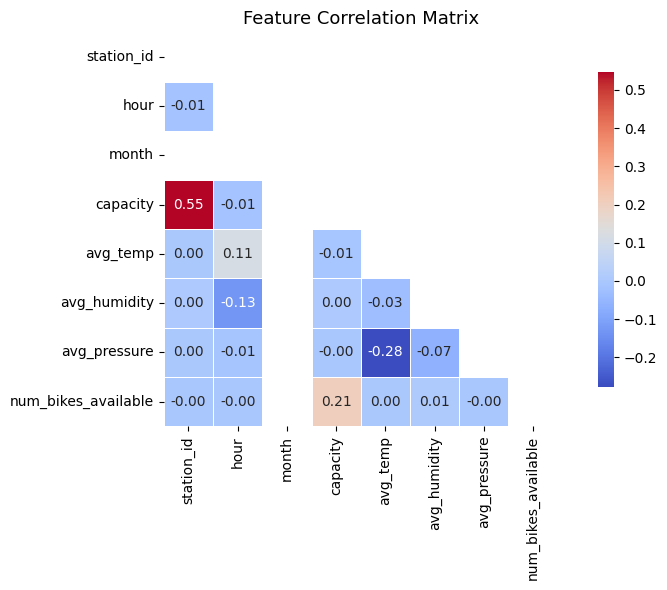

In [8]:
plt.figure(figsize=(9, 6))
corr = df[CANDIDATE_FEATURES + [REGRESSION_TARGET]].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Matrix', fontsize=13)
plt.tight_layout(); plt.show()

In [9]:
# Pearson correlations reveal strong linear predictor candidates and
# potential multicollinearity (Ridge handles this better than plain LinearRegression)

## Feature Selection — SelectKBest (F-regression)

**SelectKBest:**  
With 7 candidate features and a large dataset, SelectKBest with F-regression scores each feature's **univariate** linear relationship with the target and keeps only the top *k*. This removes features that contribute pure noise and speeds up RandomForest training (which must build 100 trees across all features).

**force-include `station_id`:**  
SelectKBest uses a *univariate* F-statistic — station IDs are integer identifiers with no meaningful ordinal relationship, so their univariate F-score appears misleadingly low. In a tree-based model, `station_id` is used via branching: the forest learns that station 10 is busy at 8am and quiet at 2pm. We therefore always include it regardless of its SelectKBest ranking.


In [10]:
K = 5
X_all = df[CANDIDATE_FEATURES]
y_all = df[REGRESSION_TARGET]

selector = SelectKBest(f_regression, k=K)
selector.fit(X_all, y_all)

scores_df = pd.DataFrame({
    'Feature'  : CANDIDATE_FEATURES,
    'F-Score'  : selector.scores_,
    'Selected' : selector.get_support()
}).sort_values('F-Score', ascending=False).reset_index(drop=True)

print(f'SelectKBest results (k={K}):')
print(scores_df.to_string(index=False))

kbest_features = scores_df[scores_df['Selected']]['Feature'].tolist()
SELECTED_FEATURES = list(dict.fromkeys(['station_id'] + kbest_features))
print(f'\n Final feature set (SelectKBest + station_id): {SELECTED_FEATURES}')

SelectKBest results (k=5):
     Feature      F-Score  Selected
    capacity 13121.042326      True
avg_humidity    22.409272      True
        hour     6.756964      True
avg_pressure     1.356716      True
    avg_temp     1.209129      True
  station_id     0.550011     False
       month     0.000000     False

 Final feature set (SelectKBest + station_id): ['station_id', 'capacity', 'avg_humidity', 'hour', 'avg_pressure', 'avg_temp']


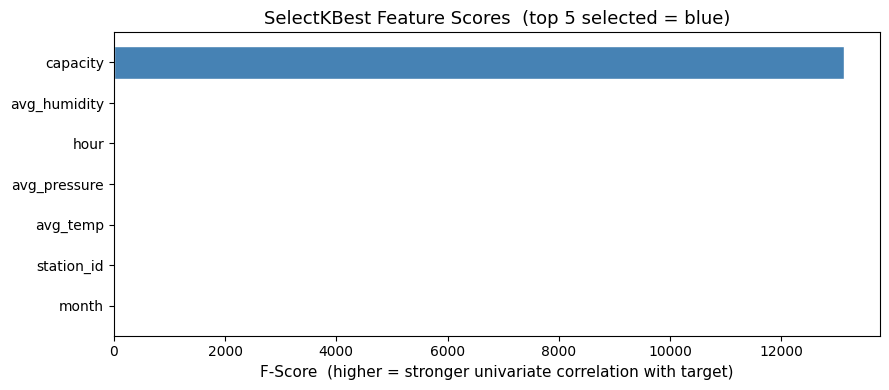

In [11]:
# Blue = selected by SelectKBest; grey = dropped.
colours = ['steelblue' if s else 'lightgrey' for s in scores_df['Selected']]
plt.figure(figsize=(9, 4))
bars = plt.barh(scores_df['Feature'], scores_df['F-Score'], color=colours, edgecolor='white')
plt.xlabel('F-Score  (higher = stronger univariate correlation with target)', fontsize=11)
plt.title(f'SelectKBest Feature Scores  (top 5 selected = blue)', fontsize=13)
plt.gca().invert_yaxis(); plt.tight_layout(); plt.show()

##  Regression — Predict Exact Bike Count

LinearRegression -> Simplest baseline; fast to train; fully interpretable via coefficients


**MAE over RMSE:**  
MAE is expressed in the original unit (bikes) and is not disproportionately affected by a few large errors. It is the most user-friendly metric for this domain.

**70/30 split with `random_state=42`:**  
A 30% test set is large enough for stable metric estimates. `random_state=42` makes results exactly reproducible across all team members and CI runs.

In [12]:
X = df[SELECTED_FEATURES]
y = df[REGRESSION_TARGET]

# shuffle=True (default) prevents time-ordering bias.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)
print(f'Train: {len(X_train):,} rows   Test: {len(X_test):,} rows')

Train: 209,262 rows   Test: 89,684 rows


In [13]:
# n_estimators=100: de-facto default; more trees reduce variance with diminishing returns.
# n_jobs=-1: use all CPU cores to speed up training.
# Ridge alpha=1.0: default regularisation strength, already well-regularised.
regression_candidates = {
    'LinearRegression': LinearRegression(),
    'Ridge'           : Ridge(alpha=1.0),
    'RandomForest'    : RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-True),
}

reg_results = {}
print(f'{"Algorithm":<22}  {"MAE":>8}  {"R²":>8}')
print('-' * 44)

for name, model in regression_candidates.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, pred)
    r2 = r2_score(y_test, pred)
    reg_results[name] = {'model': model, 'mae': mae, 'r2': r2, 'pred': pred}
    print(f'{name:<22}  {mae:>8.4f}  {r2:>8.4f}')

best_name = min(reg_results, key=lambda k: reg_results[k]['mae'])
best = reg_results[best_name]
print(f'\n   Best regression model: {best_name}  (MAE={best["mae"]:.4f}, R²={best["r2"]:.4f})')

Algorithm                    MAE        R²
--------------------------------------------
LinearRegression          7.9127    0.0607
Ridge                     7.9127    0.0607
RandomForest              1.4342    0.9319

   Best regression model: RandomForest  (MAE=1.4342, R²=0.9319)


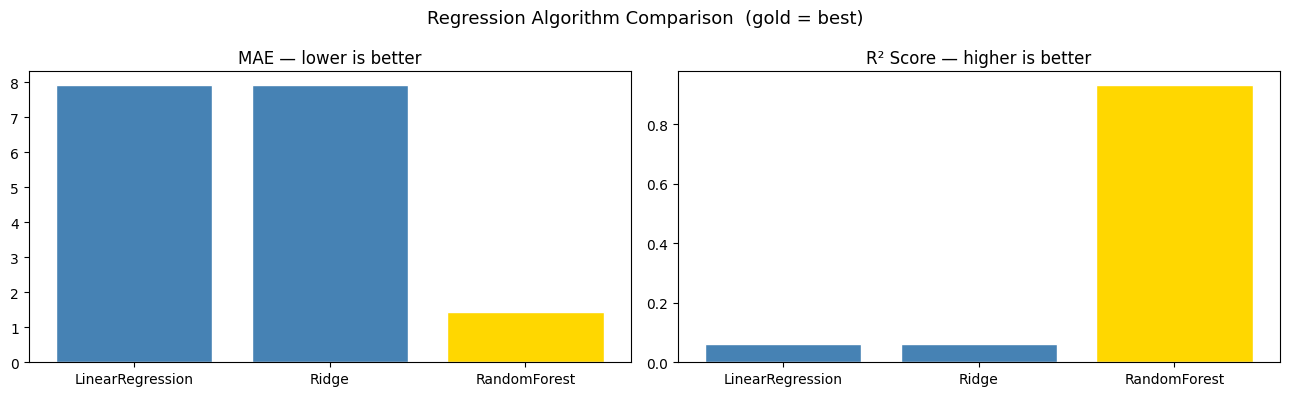

In [14]:
# Gold bar = winning algorithm.
# Showing both MAE and R² catches edge cases where MAE looks good simply
# because overall variance is low.
names = list(reg_results.keys())
maes = [reg_results[n]['mae'] for n in names]
r2s = [reg_results[n]['r2']  for n in names]
bar_colours = ['gold' if n == best_name else 'steelblue' for n in names]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(names, maes, color=bar_colours, edgecolor='white')
axes[0].set_title('MAE — lower is better', fontsize=12)
axes[1].bar(names, r2s, color=bar_colours, edgecolor='white')
axes[1].set_title('R² Score — higher is better', fontsize=12)
fig.suptitle('Regression Algorithm Comparison  (gold = best)', fontsize=13)
plt.tight_layout(); plt.show()

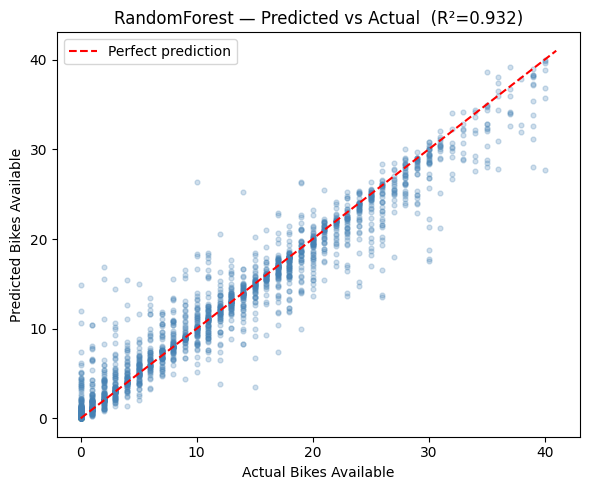

In [15]:
# Bar charts show only aggregate metrics. The scatter plot reveals the pattern
# of errors: are errors random (ideal) or systematic
# Let's take sample 2000 points to avoid over-plotting on a dense test set.
rng        = np.random.default_rng(0)
sample_idx = rng.choice(len(y_test), size=min(2000, len(y_test)), replace=False)
y_samp     = np.array(y_test)[sample_idx]
p_samp     = best['pred'][sample_idx]

plt.figure(figsize=(6, 5))
plt.scatter(y_samp, p_samp, alpha=0.25, s=12, color='steelblue')
lim = max(y_samp.max(), p_samp.max()) + 1
plt.plot([0, lim], [0, lim], 'r--', linewidth=1.5, label='Perfect prediction')
plt.xlabel('Actual Bikes Available'); plt.ylabel('Predicted Bikes Available')
plt.title(f'{best_name} — Predicted vs Actual  (R²={best["r2"]:.3f})', fontsize=12)
plt.legend(); plt.tight_layout(); plt.show()

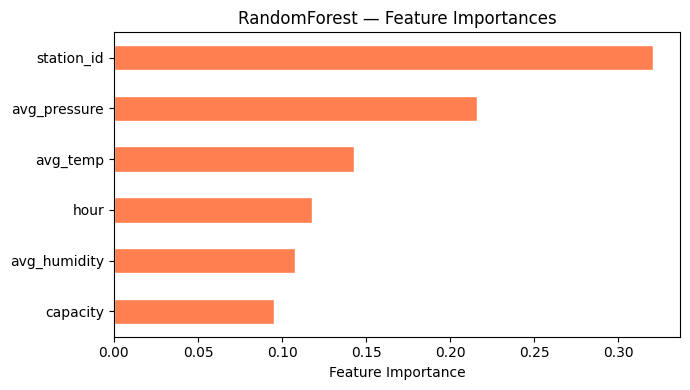

In [16]:
#  Feature importances show which features actually drove splitting decisions
#  inside the trees — as opposed to the univariate F-scores from SelectKBest.
#  If station_id dominates (expected), this validates our force-include decision.
rf_model    = reg_results['RandomForest']['model']
importances = pd.Series(rf_model.feature_importances_, index=SELECTED_FEATURES).sort_values()

plt.figure(figsize=(7, 4))
importances.plot(kind='barh', color='coral', edgecolor='white')
plt.xlabel('Feature Importance')
plt.title('RandomForest — Feature Importances', fontsize=12)
plt.tight_layout(); plt.show()

In [19]:
MODEL_PATH = '../bike_forecast/bike_model.pkl'
META_PATH  = '../bike_forecast/model_meta.json'

with open(MODEL_PATH, 'wb') as f:
    pickle.dump(best['model'], f)

meta = {
    'best_model': best_name,
    'features'  : SELECTED_FEATURES,
    'mae'       : round(best['mae'], 4),
    'r2'        : round(best['r2'],  4),
    'target'    : REGRESSION_TARGET,
}
with open(META_PATH, 'w') as f:
    json.dump(meta, f, indent=2)

print(f'Model saved  → {MODEL_PATH}')
print(f'Meta saved   → {META_PATH}')
print()
print(json.dumps(meta, indent=2))

Model saved  → ../bike_forecast/bike_model.pkl
Meta saved   → ../bike_forecast/model_meta.json

{
  "best_model": "RandomForest",
  "features": [
    "station_id",
    "capacity",
    "avg_humidity",
    "hour",
    "avg_pressure",
    "avg_temp"
  ],
  "mae": 1.4342,
  "r2": 0.9319,
  "target": "num_bikes_available"
}
